# ScienceQA Visual Challenge — Optimized Notebook

**Strategy summary:**
- **Model**: `HuggingFaceTB/SmolVLM-500M-Instruct` (required by rules)
- **Fine-tuning**: QLoRA (4-bit NF4), LoRA r=16 on all attention projections — verified ≤5M trainable params
- **Inference**: Log-likelihood scoring over each choice letter (replaces unreliable generation)
- **Prompts**: lecture + hint + solution (chain-of-thought) during training
- **Augmentation**: Random choice-order shuffling to prevent positional bias
- **Final model**: Retrained on train+val combined before submission
- **Ensemble**: 3 seeds, average log-probs (optional section at bottom)

In [1]:
# ── 0. Install ────────────────────────────────────────────────────────────────
# transformers 4.47.1: Idefics3Processor works correctly, no vmap masking bug.
# The vmap-based masking_utils that crash with bitsandbytes 4-bit landed in 4.48.
!pip install -q transformers==4.47.1 peft==0.14.0 bitsandbytes accelerate datasets pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/44.1 kB ? eta -:--:--

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.3 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/10.1 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 4.4/10.1 MB 135.8 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 10.1/10.1 MB 163.7 MB/s eta 0:00:01

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 60.7/60.7 MB 237.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 60.7/60.7 MB 237.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 60.7/60.7 MB 237.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.8 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.6 MB/s eta 0:00:00


In [2]:
# ── 1. Imports & Configuration ────────────────────────────────────────────────
import os
import gc
import json
import random
from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from transformers import (
    Idefics3Processor,
    Idefics3ForConditionalGeneration,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path("/kaggle/input/datasets/komvopoulos/finalexamdataset")

# ── Model & training knobs ────────────────────────────────────────────────────
MODEL_ID       = "HuggingFaceTB/SmolVLM-500M-Instruct"
# SigLIP (SmolVLM's vision encoder) has a native resolution of 384×384.
# Using 224 discards ~75% of visual information.
IMG_SIZE       = 384
LORA_R         = 8
LORA_ALPHA     = 16
LORA_DROPOUT   = 0.05
LR             = 1e-4
NUM_EPOCHS     = 3
BATCH_SIZE     = 2
GRAD_ACCUM     = 8
CHOICE_LETTERS = "ABCDEFGHIJ"
PARAM_BUDGET   = 5_000_000

# ── Text-field limits ─────────────────────────────────────────────────────────
INCLUDE_LECTURE     = True
SOLUTION_MAX_CHARS  = 400
TRAIN_WITH_SOLUTION = False   # no solution mismatch: test has no solutions

# ── Cross-session checkpoint resume ──────────────────────────────────────────
# Same session (crash/timeout → re-run): leave as None — auto-detected below.
# New session (prev output attached as dataset): set to the checkpoint folder,
#   e.g. "/kaggle/input/my-prev-output/qlora-final/checkpoint-150"
RESUME_CHECKPOINT_PATH = None

# ── System prompt (ChatML format) ─────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are an expert science educator. "
    "Carefully analyze the image and all provided context, "
    "then select the single best answer from the choices."
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

2026-05-03 18:47:59.731572: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777834080.146424      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777834080.263252      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777834081.277527      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777834081.277571      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777834081.277574      23 computation_placer.cc:177] computation placer alr

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Load Data

In [3]:
# ── 2a. Load CSVs ─────────────────────────────────────────────────────────────
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(json.loads)

# Detect whether solution is available at test time.
# In ScienceQA the test split typically omits solutions since they reveal the answer.
# We check dynamically so the code works either way.
TEST_HAS_SOLUTION = (
    "solution" in test_df.columns
    and test_df["solution"].notna().any()
    and test_df["solution"].astype(str).str.strip().ne("").any()
)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Solution available in test.csv: {TEST_HAS_SOLUTION}")
print(f"Test columns: {test_df.columns.tolist()}")
train_df.head(2)

Train: 3,109 | Val: 1,048 | Test: 1,008
Solution available in test.csv: False
Test columns: ['id', 'image_path', 'question', 'choices', 'num_choices', 'hint', 'lecture', 'task', 'grade', 'subject', 'topic', 'category', 'skill']


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool...,[the male's tadpoles will be larger when they ...,3,2,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with oth...,"[the female's offspring will live longer, the ...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...


In [4]:
# ── Dataset feature audit ─────────────────────────────────────────────────────
# Run this cell to see every available column: fill rate, unique values, samples.

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{'='*70}")
    print(f"  {split_name.upper()}  —  {len(df):,} rows  ×  {len(df.columns)} columns")
    print(f"{'='*70}")
    for col in df.columns:
        series = df[col]
        n_null  = series.isna().sum()

        first_valid = series.dropna().iloc[0] if series.notna().any() else None
        is_list_col = isinstance(first_valid, list)

        n_empty = (series.astype(str).str.strip() == "").sum() if not is_list_col else 0
        fill    = 100 * (1 - (n_null + n_empty) / len(df))
        dtype   = str(series.dtype)

        if is_list_col:
            uniq = "n/a (list)"
        else:
            try:
                uniq = series.nunique(dropna=True)
            except TypeError:
                uniq = "unhashable"

        samples = series.dropna().head(3).tolist()
        sample_str = " | ".join(repr(str(v)[:60]) for v in samples)

        print(f"\n  [{col}]  dtype={dtype}  fill={fill:.1f}%  unique={uniq}")
        print(f"    samples: {sample_str}")

        if isinstance(uniq, int) and uniq <= 20 and col not in ("id", "answer", "image_path"):
            vc = series.value_counts(dropna=False).head(10)
            for val, cnt in vc.items():
                bar = "█" * int(20 * cnt / len(df))
                print(f"    {str(val):<30} {cnt:5d}  {bar}")

print(f"\n{'='*70}")
print("  FIELDS USED IN PROMPT:")
print(f"    subject, topic, category, grade  (metadata header)")
print(f"    skill                            (cognitive objective)")
print(f"    lecture  (INCLUDE_LECTURE={INCLUDE_LECTURE})")
print(f"    hint     (always included when present)")
print(f"    solution (EXCLUDED — TRAIN_WITH_SOLUTION={TRAIN_WITH_SOLUTION}, TEST_HAS_SOLUTION={{}})")
print(f"  FIELDS NOT USED IN PROMPT:")
print(f"    num_choices, task  (redundant)")
print(f"{'='*70}")


  TRAIN  —  3,109 rows  ×  15 columns

  [id]  dtype=object  fill=100.0%  unique=3109
    samples: 'train_07667' | 'train_02628' | 'train_00927'

  [image_path]  dtype=object  fill=100.0%  unique=3109
    samples: 'images/train/train_07667.png' | 'images/train/train_02628.png' | 'images/train/train_00927.png'

  [question]  dtype=object  fill=100.0%  unique=1150
    samples: 'Why might putting each tadpole in its own pool of water incr' | 'Why might forming strong social bonds with other females inc' | 'Why might raising cubs with other lionesses in a pride incre'

  [choices]  dtype=object  fill=100.0%  unique=n/a (list)
    samples: '["the male\'s tadpoles will be larger when they hatch", \'the ' | '["the female\'s offspring will live longer", \'the female will' | '["the lioness\'s cubs will be around other cubs", "the liones'

  [num_choices]  dtype=int64  fill=100.0%  unique=4
    samples: '3' | '3' | '3'
    3                               1552  █████████
    4                   

In [5]:
# ── 2b. Prompt Engineering ────────────────────────────────────────────────────

def _trunc(text: str, max_chars: int) -> str:
    text = str(text).strip()
    return text if len(text) <= max_chars else text[:max_chars] + "…"


def _get(row, key: str, default=""):
    """Safely read a field from either a dict or a pandas row."""
    if isinstance(row, dict):
        val = row.get(key, default)
    else:
        val = getattr(row, key, default)
    return default if val is None or (isinstance(val, float) and val != val) else val


def build_prompt(row, include_answer: bool = False, include_solution: bool = False) -> str:
    """
    ChatML layout
    ─────────────
    <|im_start|>system
    {SYSTEM_PROMPT}<|im_end|>
    <|im_start|>user
    <image>
    Subject: … | Topic: … | Category: … | Grade: …
    Skill: …

    Context:
    <lecture>

    <hint>

    Question: …
    Choices:
      A. …
      B. …<|im_end|>
    <|im_start|>assistant
    Answer: [X]<|im_end|>        ← include_answer=True  (training)
    Answer:                      ← include_answer=False (inference base)
    """

    # ── 1. Metadata header ────────────────────────────────────────────────────
    meta_parts = []
    for key, label in [("subject",  "Subject"),
                       ("topic",    "Topic"),
                       ("category", "Category"),
                       ("grade",    "Grade")]:
        val = str(_get(row, key, "")).strip()
        if val:
            if key == "grade":
                val = val.replace("grade", "Grade ")
            meta_parts.append(f"{label}: {val}")

    skill = str(_get(row, "skill", "")).strip()

    # ── 2. Context block ──────────────────────────────────────────────────────
    context_parts = []

    if INCLUDE_LECTURE:
        lecture = str(_get(row, "lecture", "")).strip()
        if lecture:
            context_parts.append(_trunc(lecture, 500))

    hint = str(_get(row, "hint", "")).strip()
    if hint:
        context_parts.append(hint)

    if include_solution:
        sol = str(_get(row, "solution", "")).strip()
        if sol:
            context_parts.append("Reasoning: " + _trunc(sol, SOLUTION_MAX_CHARS))

    # ── 3. Question & choices ─────────────────────────────────────────────────
    choices = _get(row, "choices", [])
    if not isinstance(choices, list):
        choices = []
    choices_str = "\n".join(
        f"  {CHOICE_LETTERS[i]}. {c}" for i, c in enumerate(choices)
    )
    question = str(_get(row, "question", "")).strip()

    # ── 4. Assemble user message ──────────────────────────────────────────────
    user_msg = "<image>\n"
    if meta_parts:
        user_msg += " | ".join(meta_parts) + "\n"
    if skill:
        user_msg += f"Skill: {skill}\n"
    if meta_parts or skill:
        user_msg += "\n"
    if context_parts:
        user_msg += "Context:\n" + "\n\n".join(context_parts) + "\n\n"
    user_msg += f"Question: {question}\n"
    user_msg += f"Choices:\n{choices_str}"

    # ── 5. Wrap in ChatML ─────────────────────────────────────────────────────
    prompt  = f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
    prompt += f"<|im_start|>user\n{user_msg}<|im_end|>\n"
    prompt += f"<|im_start|>assistant\n"
    prompt += "Answer:"

    if include_answer:
        letter = CHOICE_LETTERS[int(_get(row, "answer"))]
        prompt += f" {letter}<|im_end|>"

    return prompt


# ── Sanity-print a sample to verify layout ────────────────────────────────────
sample = build_prompt(train_df.iloc[0].to_dict(), include_answer=True, include_solution=False)
print(f"Sample prompt ({len(sample)} chars):\n")
print(sample)

Sample prompt (2381 chars):

<|im_start|>system
You are an expert science educator. Carefully analyze the image and all provided context, then select the single best answer from the choices.<|im_end|>
<|im_start|>user
<image>
Subject: natural science | Topic: literacy-in-science | Category: Adaptations and natural selection | Grade: Grade 8
Skill: How can animal behaviors affect reproductive success? Identify evidence to support a claim

Context:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to rep…

Animals often behave in certain ways that can 

In [6]:
# ── 2c. Dataset with choice-order augmentation ────────────────────────────────

class ScienceQADataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        data_dir: Path,
        img_size: int = IMG_SIZE,
        is_train: bool = True,
        augment_choices: bool = False,
        include_solution: bool = False,
    ):
        self.df               = df.reset_index(drop=True)
        self.data_dir         = data_dir
        self.img_size         = img_size
        self.is_train         = is_train
        self.augment_choices  = augment_choices
        self.include_solution = include_solution

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx].to_dict()

        img = Image.open(self.data_dir / "images" / row["image_path"]).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BICUBIC)

        if self.augment_choices and self.is_train:
            choices = list(row["choices"])
            answer  = int(row["answer"])
            perm    = list(range(len(choices)))
            random.shuffle(perm)
            row["choices"] = [choices[p] for p in perm]
            row["answer"]  = perm.index(answer)

        if self.is_train:
            return {
                "image": img,
                "text":  build_prompt(row, include_answer=True,
                                      include_solution=self.include_solution),
                "answer": int(row["answer"]),
            }
        else:
            return {
                "image":   img,
                "text":    build_prompt(row, include_answer=False,
                                        include_solution=self.include_solution),
                "choices": row["choices"],
                "answer":  int(row["answer"]) if "answer" in row and pd.notna(row.get("answer")) else -1,
                "id":      row.get("id", ""),
            }

# Training uses TRAIN_WITH_SOLUTION=True for chain-of-thought supervision.
# Val/test use TEST_HAS_SOLUTION to match the inference prompt format exactly.
train_ds = ScienceQADataset(train_df, DATA_DIR, is_train=True,
                            augment_choices=True,
                            include_solution=TRAIN_WITH_SOLUTION)
val_ds   = ScienceQADataset(val_df,   DATA_DIR, is_train=False,
                            include_solution=TEST_HAS_SOLUTION)
test_ds  = ScienceQADataset(test_df,  DATA_DIR, is_train=False,
                            include_solution=TEST_HAS_SOLUTION)

print(f"Datasets — train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")
print(f"Training with solution: {TRAIN_WITH_SOLUTION}")
print(f"Inference with solution: {TEST_HAS_SOLUTION}")

Datasets — train: 3109 | val: 1048 | test: 1008
Training with solution: False
Inference with solution: False


/tmp/ipykernel_23/4211105769.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


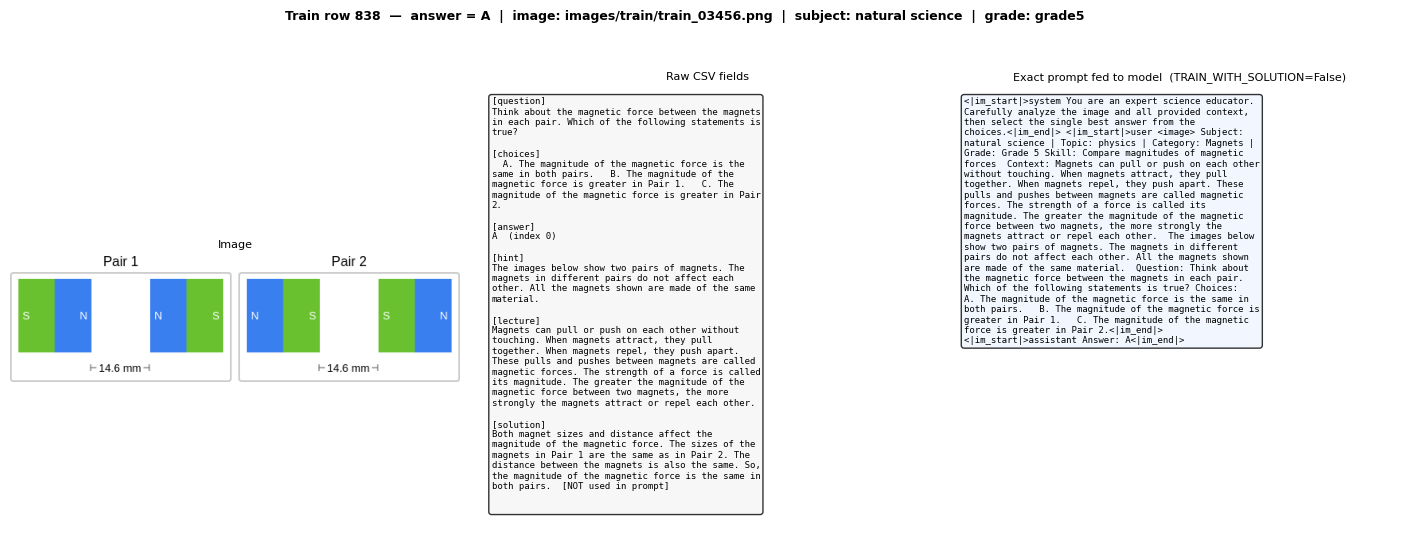

  Row  838 | ~chars/4: 309



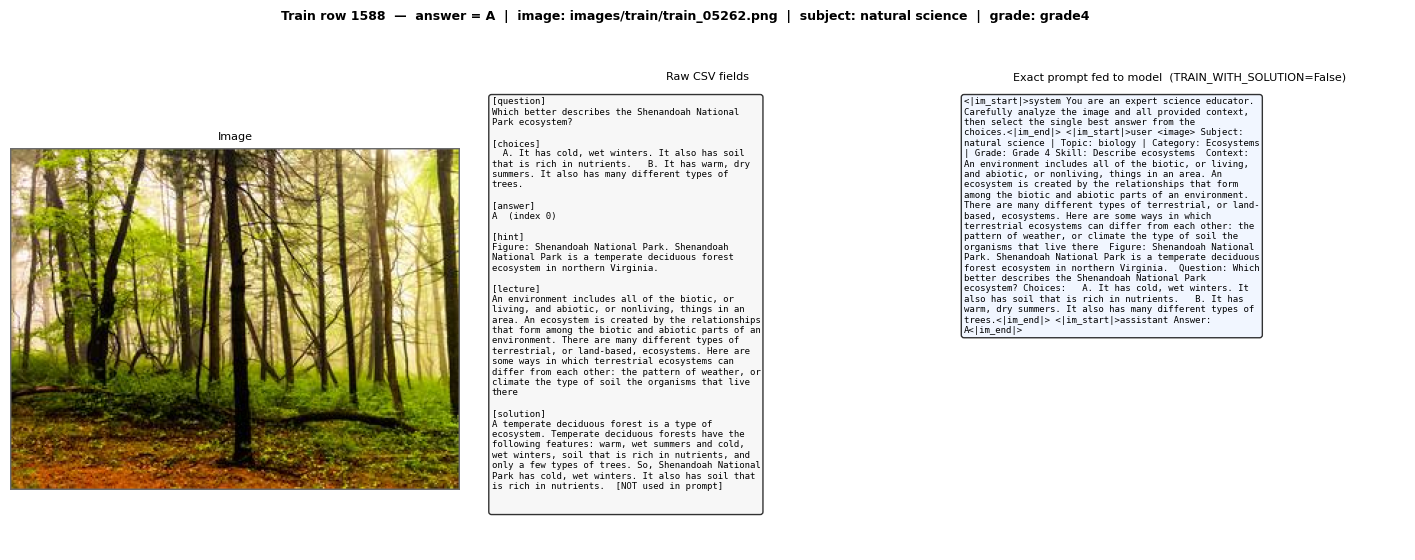

  Row 1588 | ~chars/4: 291



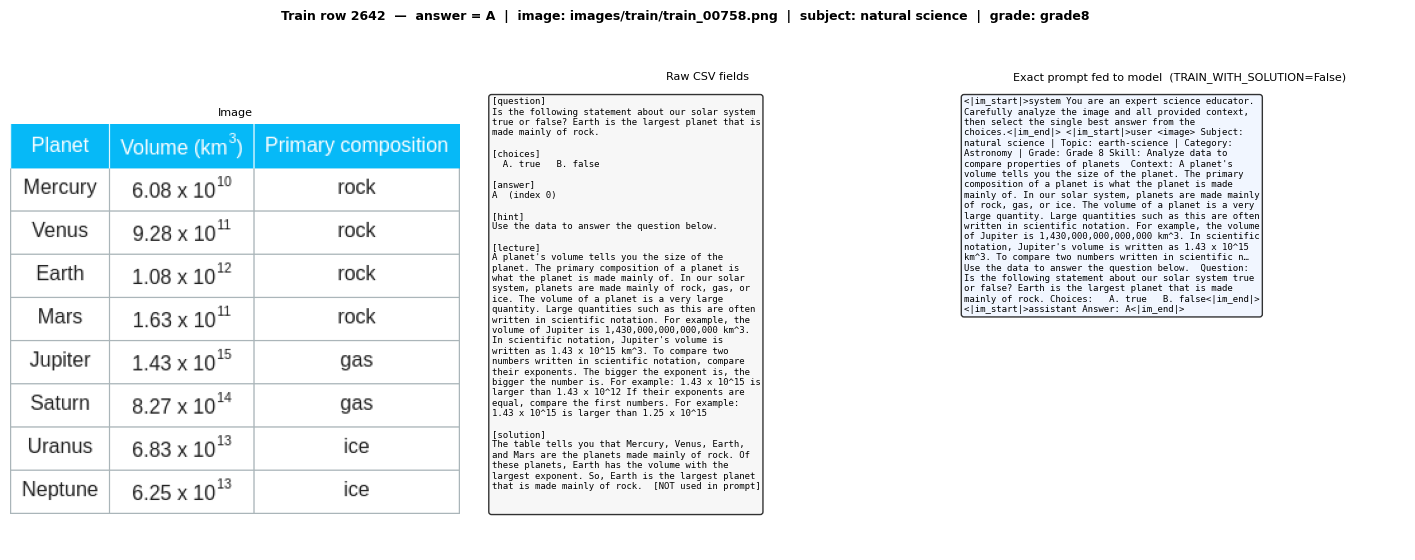

  Row 2642 | ~chars/4: 276



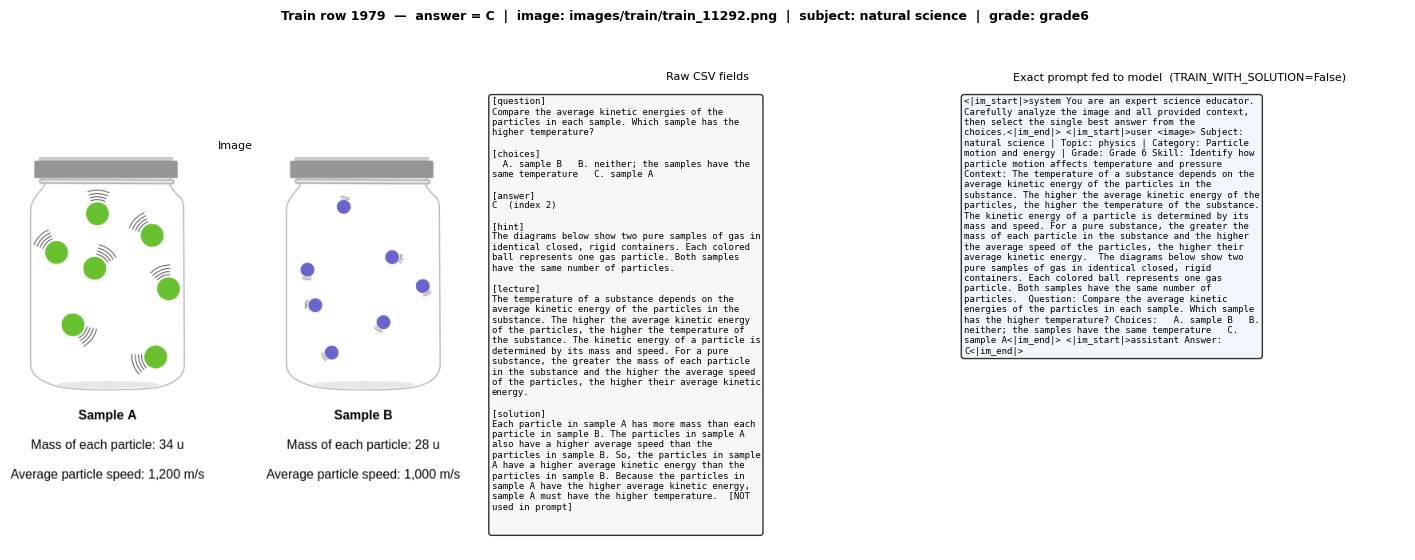

  Row 1979 | ~chars/4: 315



In [7]:
# ── Sample viewer — run after cell-dataset to inspect training examples ────────
# Shows N samples: raw fields on the left, actual training prompt on the right.
# Change SHOW_N or SAMPLE_INDICES to inspect specific rows.

import textwrap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SHOW_N         = 4       # how many samples to display
SAMPLE_INDICES = None    # None = random; or e.g. [0, 5, 100, 200] for specific rows

rng = np.random.default_rng(0)
indices = (
    SAMPLE_INDICES
    if SAMPLE_INDICES is not None
    else rng.choice(len(train_df), size=SHOW_N, replace=False).tolist()
)

def _wrap(text, width=52):
    return "\n".join(textwrap.wrap(str(text), width))

def _count_tokens(text):
    try:
        return len(processor.tokenizer(text)["input_ids"])
    except NameError:
        return len(text) // 4

for idx in indices:
    row = train_df.iloc[idx].to_dict()

    img_path = DATA_DIR / "images" / row["image_path"]
    img = (
        Image.open(img_path).convert("RGB")
        if img_path.exists()
        else Image.new("RGB", (224, 224), (180, 180, 180))
    )

    # Use the exact same flags as actual training
    actual_prompt = build_prompt(row, include_answer=True,
                                 include_solution=TRAIN_WITH_SOLUTION)
    answer_letter = CHOICE_LETTERS[int(row["answer"])]

    fig = plt.figure(figsize=(18, 6))
    fig.suptitle(
        f"Train row {idx}  —  answer = {answer_letter}  |  "
        f"image: {row['image_path']}  |  subject: {row.get('subject','?')}  |  "
        f"grade: {row.get('grade','?')}",
        fontsize=9, fontweight="bold", y=1.01,
    )
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.05)

    # Panel 1 — image
    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(img)
    ax_img.axis("off")
    ax_img.set_title("Image", fontsize=8)

    # Panel 2 — raw CSV fields
    ax_raw = fig.add_subplot(gs[1])
    ax_raw.axis("off")
    fields = [
        ("question", row.get("question", "")),
        ("choices",  "\n".join(f"  {CHOICE_LETTERS[i]}. {c}"
                               for i, c in enumerate(row["choices"]))),
        ("answer",   f"{answer_letter}  (index {row['answer']})"),
        ("hint",     row.get("hint", "—")),
        ("lecture",  row.get("lecture", "—")),
        ("solution", row.get("solution", "—") + "  [NOT used in prompt]"),
    ]
    raw_text = ""
    for label, value in fields:
        raw_text += f"[{label}]\n{_wrap(value, 50)}\n\n"
    ax_raw.text(
        0.02, 0.98, raw_text,
        transform=ax_raw.transAxes,
        va="top", ha="left", fontsize=6.5,
        fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="#f5f5f5", alpha=0.8),
    )
    ax_raw.set_title("Raw CSV fields", fontsize=8)

    # Panel 3 — exact prompt fed to the model (no solution)
    ax_prompt = fig.add_subplot(gs[2])
    ax_prompt.axis("off")
    ax_prompt.text(
        0.02, 0.98, _wrap(actual_prompt, 55),
        transform=ax_prompt.transAxes,
        va="top", ha="left", fontsize=6.5,
        fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="#eef4ff", alpha=0.8),
    )
    ax_prompt.set_title(
        f"Exact prompt fed to model  (TRAIN_WITH_SOLUTION={TRAIN_WITH_SOLUTION})",
        fontsize=8,
    )

    plt.tight_layout()
    plt.show()

    n_tok = _count_tokens(actual_prompt)
    mode  = "tokens" if "processor" in dir() else "~chars/4"
    print(f"  Row {idx:4d} | {mode}: {n_tok}")
    print()

## 3. Load Model with QLoRA

The parameter budget is **5 million trainable params**. With `r=16` on the four attention projections (`q, k, v, o`) of SmolVLM-500M's language backbone this lands at roughly 2–4 M params — safely within budget. `model.print_trainable_parameters()` shows the exact count. If it exceeds 5 M, change `LORA_R = 8`.

In [8]:
# ── 3. Load SmolVLM-500M with 4-bit QLoRA ────────────────────────────────────

def load_model_and_processor(model_id: str = MODEL_ID, lora_r: int = LORA_R):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    # Use Idefics3Processor directly — AutoProcessor's auto-mapping for this
    # class is missing in transformers 4.47.x, causing it to return GPT2TokenizerFast.
    proc = Idefics3Processor.from_pretrained(model_id)
    if proc.tokenizer.pad_token is None:
        proc.tokenizer.pad_token = proc.tokenizer.eos_token
    proc.tokenizer.padding_side = "right"

    base = Idefics3ForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
    )
    base = prepare_model_for_kbit_training(base, use_gradient_checkpointing=True)

    lora_cfg = LoraConfig(
        r=lora_r,
        lora_alpha=LORA_ALPHA,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_dropout=LORA_DROPOUT,
        bias="none",
        task_type="CAUSAL_LM",
    )
    mdl = get_peft_model(base, lora_cfg)
    mdl.enable_input_require_grads()

    trainable, total = mdl.get_nb_trainable_parameters()
    print(f"Trainable params : {trainable:,} / {total:,}  ({100 * trainable / total:.3f}%)")
    assert trainable <= PARAM_BUDGET, (
        f"Trainable params {trainable:,} exceed budget {PARAM_BUDGET:,}. "
        "Reduce LORA_R and re-run."
    )
    print(f"padding_side     : {proc.tokenizer.padding_side}")
    print(f"pad_token_id     : {proc.tokenizer.pad_token_id}  ({proc.tokenizer.pad_token!r})")
    print(f"eos_token_id     : {proc.tokenizer.eos_token_id}  ({proc.tokenizer.eos_token!r})")
    return mdl, proc


model, processor = load_model_and_processor()

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some kwargs in processor config are unused and will not have any effect: image_seq_len. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Trainable params : 4,784,128 / 512,266,432  (0.934%)
padding_side     : right
pad_token_id     : 2  ('<|im_end|>')
eos_token_id     : 49279  ('<end_of_utterance>')


In [9]:
# ── 4. Collate function — answer-token label masking ─────────────────────────
#
# Training text ends: "…Answer: X<|im_end|>"
# Walk backward past EOS, PAD, and <|im_end|> to find the answer letter X.
# Label only that one position; everything else is -100 (ignored by the loss).

def collate_fn(batch, proc):
    texts  = [item["text"]  for item in batch]
    images = [item["image"] for item in batch]

    proc.tokenizer.padding_side = "right"
    inputs = proc(text=texts, images=images, return_tensors="pt", padding=True)

    eos_id    = proc.tokenizer.eos_token_id
    pad_id    = proc.tokenizer.pad_token_id
    # <|im_end|> may equal eos_token or be a distinct special token — skip both.
    im_end_id = proc.tokenizer.convert_tokens_to_ids("<|im_end|>")
    skip_ids  = {eos_id, pad_id, im_end_id}

    labels = torch.full_like(inputs["input_ids"], -100)

    for i in range(labels.shape[0]):
        seq = inputs["input_ids"][i].tolist()

        answer_pos = len(seq) - 1
        while answer_pos >= 0 and seq[answer_pos] in skip_ids:
            answer_pos -= 1

        if answer_pos >= 0:
            labels[i, answer_pos] = inputs["input_ids"][i, answer_pos]

    inputs["labels"] = labels
    return inputs


_collate = partial(collate_fn, proc=processor)

In [10]:
# ── 4b. Pre-training sanity checks ───────────────────────────────────────────
# Runs BEFORE training. All checks must pass (no "FAIL" lines) before proceeding.
#
# CHECK A: collate_fn label positions — verifies the answer token is found.
# CHECK B: forward-pass loss — verifies the initial loss is finite and >0.
#
# If CHECK A fails: the collate_fn cannot find the answer token (padding bug).
# If CHECK B fails: labels are all -100 (loss=NaN) or model is broken.

print(f"{'='*65}")
print(f" Tokenizer  padding_side : {processor.tokenizer.padding_side}")
print(f"            pad_token_id : {processor.tokenizer.pad_token_id}")
print(f"            eos_token_id : {processor.tokenizer.eos_token_id}")
print(f"{'='*65}\n")

# ── CHECK A: label positions ──────────────────────────────────────────────────
print("── CHECK A: label positions ─────────────────────────────────────────")
_items = [train_ds[i] for i in range(4)]
_batch = _collate(_items)

eos_id = processor.tokenizer.eos_token_id
pad_id = processor.tokenizer.pad_token_id
check_a_ok = True

for i, item in enumerate(_items):
    seq    = _batch["input_ids"][i].tolist()
    labels = _batch["labels"][i].tolist()
    labeled = [p for p, l in enumerate(labels) if l != -100]
    expected = CHOICE_LETTERS[item["answer"]]

    print(f"  Sample {i}  (expected: {expected})")
    print(f"    seq length     : {len(seq)}")
    print(f"    labeled pos(s) : {labeled}")

    # Last 6 real tokens
    last_real = [p for p, m in enumerate(_batch["attention_mask"][i].tolist()) if m == 1][-6:]
    tokens_str = [(processor.tokenizer.decode([seq[p]]), seq[p]) for p in last_real]
    print(f"    last 6 tokens  : {tokens_str}")

    if len(labeled) == 0:
        print(f"    FAIL: no labeled position — collate_fn did not find the answer token")
        check_a_ok = False
    elif len(labeled) > 1:
        print(f"    FAIL: {len(labeled)} labeled positions (expected 1)")
        check_a_ok = False
    else:
        pos    = labeled[0]
        tok_id = seq[pos]
        tok_str = processor.tokenizer.decode([tok_id]).strip()
        if tok_id in (eos_id, pad_id):
            print(f"    FAIL: labeled token id={tok_id} is EOS or PAD, not a letter")
            check_a_ok = False
        elif tok_str.upper() != expected:
            print(f"    FAIL: decoded '{tok_str}' != expected '{expected}'")
            check_a_ok = False
        else:
            print(f"    OK  : token '{tok_str}' at pos {pos} matches '{expected}'")
    print()

# ── CHECK B: forward-pass loss ────────────────────────────────────────────────
print("── CHECK B: forward-pass loss ───────────────────────────────────────")
model.eval()
with torch.no_grad():
    _dev_batch = {k: v.to(model.device) if torch.is_tensor(v) else v
                  for k, v in _batch.items()}
    out = model(**_dev_batch)
    loss_val = out.loss.item()

if loss_val != loss_val:  # NaN check
    print(f"  FAIL: loss = NaN — labels are probably all -100 (collate_fn bug)")
    check_b_ok = False
elif loss_val < 0.01:
    print(f"  FAIL: loss = {loss_val:.4f} — suspiciously near zero before any training")
    check_b_ok = False
elif loss_val > 20:
    print(f"  WARN: loss = {loss_val:.4f} — unusually high (check inputs)")
    check_b_ok = True
else:
    print(f"  OK  : initial loss = {loss_val:.4f}  (expected ~2–5 for a random model)")
    check_b_ok = True
model.train()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
if check_a_ok and check_b_ok:
    print("  ALL CHECKS PASSED — safe to proceed to training")
else:
    print("  ONE OR MORE CHECKS FAILED — DO NOT PROCEED until fixed")
print(f"{'='*65}")

 Tokenizer  padding_side : right
            pad_token_id : 2
            eos_token_id : 49279

── CHECK A: label positions ─────────────────────────────────────────


  Sample 0  (expected: C)
    seq length     : 1615
    labeled pos(s) : [1613]
    last 6 tokens  : [('istant', 9531), ('\n', 198), ('Answer', 21350), (':', 42), (' C', 340), ('<|im_end|>', 2)]
    OK  : token 'C' at pos 1613 matches 'C'

  Sample 1  (expected: C)
    seq length     : 1615
    labeled pos(s) : [1587]
    last 6 tokens  : [('istant', 9531), ('\n', 198), ('Answer', 21350), (':', 42), (' C', 340), ('<|im_end|>', 2)]
    OK  : token 'C' at pos 1587 matches 'C'

  Sample 2  (expected: A)
    seq length     : 1615
    labeled pos(s) : [1586]
    last 6 tokens  : [('istant', 9531), ('\n', 198), ('Answer', 21350), (':', 42), (' A', 330), ('<|im_end|>', 2)]
    OK  : token 'A' at pos 1586 matches 'A'

  Sample 3  (expected: A)
    seq length     : 1615
    labeled pos(s) : [1591]
    last 6 tokens  : [('istant', 9531), ('\n', 198), ('Answer', 21350), (':', 42), (' A', 330), ('<|im_end|>', 2)]
    OK  : token 'A' at pos 1591 matches 'A'

── CHECK B: forward-pass loss ──────────

  OK  : initial loss = 2.8935  (expected ~2–5 for a random model)

  ALL CHECKS PASSED — safe to proceed to training


## 4. Training — Development Run

Train on `train_df`, evaluate on `val_df`. Use this to confirm the model learns and to pick the best epoch checkpoint. The `load_best_model_at_end=True` flag restores the lowest-val-loss checkpoint automatically.

In [11]:
# ── 4c. Smoke test — 50 samples × 1 epoch (~5 min on T4) ─────────────────────
from transformers import TrainerCallback

class VerboseCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or "loss" not in logs:
            return
        loss  = logs["loss"]
        step  = state.global_step
        epoch = logs.get("epoch", "?")
        lr    = logs.get("learning_rate", float("nan"))
        if loss != loss:
            print(f"  Step {step:4d} | epoch {epoch} | loss = NaN  ← labels may all be -100")
        elif loss < 1e-4:
            print(f"  Step {step:4d} | epoch {epoch} | loss = {loss:.6f}  ← suspiciously low")
        else:
            print(f"  Step {step:4d} | epoch {epoch} | loss = {loss:.4f} | lr = {lr:.2e}")


smoke_ds = ScienceQADataset(
    train_df.head(50), DATA_DIR,
    is_train=True, augment_choices=False,
    include_solution=TEST_HAS_SOLUTION,
)

smoke_args = TrainingArguments(
    output_dir           = "./smoke-test",
    num_train_epochs     = 1,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 2,
    learning_rate        = LR,
    lr_scheduler_type    = "cosine",
    warmup_ratio         = 0.1,
    fp16                 = True,
    bf16                 = False,
    gradient_checkpointing = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    save_strategy        = "no",
    eval_strategy        = "no",
    logging_steps        = 5,
    dataloader_num_workers = 0,
    remove_unused_columns  = False,
    report_to            = "none",
)

model.config.use_cache = False

smoke_trainer = Trainer(
    model        = model,
    args         = smoke_args,
    train_dataset= smoke_ds,
    data_collator= _collate,
    callbacks    = [VerboseCallback()],
)

print("=== SMOKE TEST START (50 samples, 1 epoch) ===")
smoke_trainer.train()
print("=== SMOKE TEST DONE ===")

=== SMOKE TEST START (50 samples, 1 epoch) ===


Step,Training Loss
5,4.574600
10,3.435800


  Step    5 | epoch 0.4 | loss = 4.5746 | lr = 5.00e-05


  Step   10 | epoch 0.8 | loss = 3.4358 | lr = 6.55e-05


=== SMOKE TEST DONE ===


In [12]:
# # ── 5. Dev training run ───────────────────────────────────────────────────────
# del model
# gc.collect()
# torch.cuda.empty_cache()

# model, processor = load_model_and_processor()
# _collate = partial(collate_fn, proc=processor)

# training_args_dev = TrainingArguments(
#     output_dir                  = "./qlora-dev",
#     num_train_epochs            = NUM_EPOCHS,
#     per_device_train_batch_size = BATCH_SIZE,
#     gradient_accumulation_steps = GRAD_ACCUM,
#     learning_rate               = LR,
#     weight_decay                = 0.01,
#     lr_scheduler_type           = "cosine",
#     warmup_ratio                = 0.1,
#     fp16                        = True,
#     bf16                        = False,
#     gradient_checkpointing      = True,
#     gradient_checkpointing_kwargs = {"use_reentrant": False},
#     save_strategy               = "no",
#     eval_strategy               = "no",
#     logging_steps               = 10,
#     dataloader_num_workers      = 0,
#     remove_unused_columns       = False,
#     report_to                   = "none",
# )

# model.config.use_cache = False

# trainer_dev = Trainer(
#     model         = model,
#     args          = training_args_dev,
#     train_dataset = train_ds,
#     data_collator = _collate,
#     callbacks     = [VerboseCallback()],
# )

# print("=== DEV TRAINING START ===")
# trainer_dev.train()
# print("=== DEV TRAINING DONE ===")

In [13]:
# # ── 5b. Save dev model (run immediately after training to avoid losing progress)
# # Saves only the LoRA adapter weights (~20 MB), not the frozen base.
# # Reload later with: model = PeftModel.from_pretrained(base, "./lora-dev-seed42")

# model.save_pretrained("./lora-dev-seed42")
# processor.save_pretrained("./lora-dev-seed42")
# print("Dev adapter saved to ./lora-dev-seed42")

## 6. Final Training on train + val

With only ~4,157 labeled examples total, every sample matters. We reload a fresh base model and retrain on the full labeled set (train + val) for the same number of epochs as the best dev run. No early stopping — we use `NUM_EPOCHS` directly.

In [14]:
# ── 7. Final training (train + val) ──────────────────────────────────────────
del model
gc.collect()
torch.cuda.empty_cache()

model, processor = load_model_and_processor()
_collate = partial(collate_fn, proc=processor)

full_df       = pd.concat([train_df, val_df], ignore_index=True)
full_train_ds = ScienceQADataset(
    full_df, DATA_DIR,
    is_train=True,
    augment_choices=True,
    include_solution=TRAIN_WITH_SOLUTION,
)

training_args_final = TrainingArguments(
    output_dir                    = "./qlora-final",
    num_train_epochs              = NUM_EPOCHS,
    per_device_train_batch_size   = BATCH_SIZE,
    gradient_accumulation_steps   = GRAD_ACCUM,
    learning_rate                 = LR,
    weight_decay                  = 0.01,
    lr_scheduler_type             = "cosine",
    warmup_ratio                  = 0.1,
    fp16                          = True,
    bf16                          = False,
    gradient_checkpointing        = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    save_strategy                 = "steps",
    save_steps                    = 50,
    save_total_limit              = 3,       # keeps last 3 checkpoints (~1.5 GB total)
    eval_strategy                 = "no",
    logging_steps                 = 10,
    dataloader_num_workers        = 0,
    remove_unused_columns         = False,
    report_to                     = "none",
)

model.config.use_cache = False

trainer_final = Trainer(
    model         = model,
    args          = training_args_final,
    train_dataset = full_train_ds,
    data_collator = _collate,
    callbacks     = [VerboseCallback()],
)

# ── Resume logic ──────────────────────────────────────────────────────────────
# Priority 1: RESUME_CHECKPOINT_PATH set manually (cross-session resume via
#             a Kaggle dataset input — set this in cell-imports).
# Priority 2: auto-detect latest checkpoint in ./qlora-final (same-session
#             crash or timeout and re-run — no config change needed).
# Priority 3: no checkpoint found → fresh start.
from transformers.trainer_utils import get_last_checkpoint

if RESUME_CHECKPOINT_PATH:
    last_ckpt = RESUME_CHECKPOINT_PATH
    print(f"=== RESUMING FROM EXTERNAL CHECKPOINT: {last_ckpt} ===")
else:
    last_ckpt = get_last_checkpoint("./qlora-final")
    if last_ckpt:
        print(f"=== RESUMING FROM LOCAL CHECKPOINT: {last_ckpt} ===")
    else:
        print("=== FINAL TRAINING START (fresh run) ===")

trainer_final.train(resume_from_checkpoint=last_ckpt)
print("=== FINAL TRAINING DONE ===")

model.save_pretrained("./lora-final-seed42")
processor.save_pretrained("./lora-final-seed42")
print("Adapter saved to ./lora-final-seed42")

Some kwargs in processor config are unused and will not have any effect: image_seq_len. 


Trainable params : 4,784,128 / 512,266,432  (0.934%)
padding_side     : right
pad_token_id     : 2  ('<|im_end|>')
eos_token_id     : 49279  ('<end_of_utterance>')
=== FINAL TRAINING START (fresh run) ===


Step,Training Loss
10,16.015700
20,13.782200
30,9.834900
40,8.460100
50,8.212100
60,8.453300
70,7.585100
80,7.508300
90,6.104600
100,6.900100


  Step   10 | epoch 0.03848003848003848 | loss = 16.0157 | lr = 6.41e-06


  Step   20 | epoch 0.07696007696007696 | loss = 13.7822 | lr = 1.79e-05


...

  Step  700 | epoch 2.7003367003367003 | loss = 3.0446 | lr = 3.52e-06


  Step  710 | epoch 2.738816738816739 | loss = 3.4896 | lr = 2.74e-06


  Step  720 | epoch 2.7772967772967774 | loss = 3.3508 | lr = 2.05e-06


  Step  730 | epoch 2.815776815776816 | loss = 2.7969 | lr = 1.47e-06


  Step  740 | epoch 2.854256854256854 | loss = 2.7027 | lr = 9.74e-07
